In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, expon, chi2

np.random.seed(42)

**• 분포의 이론적 평균/분산, 표본의 평균/분산 출력 및 분포 시각화**  
✓ α = 2, β = 3 인 감마분포 (샘플 수 = 10,000)  
✓ λ = ½ 인 지수 분포 (샘플 수 = 10,000)  
✓ 자유도가 5인 카이제곱분포 (샘플 수 = 10,000)  
  
**• 감마분포와 지수분포/카이제곱분포 분포 모양 비교**  
✓ α = 1, β = 3 인 감마분포 vs λ = ⅓ 인 지수분포  
✓ α = 3, β = 2 인 감마분포 vs 자유도가 6인 카이제곱분포  
  
**• 각 분포를 따르는 샘플 생성 시 아래의 파라미터가 각 함수 안에 사용**  
✓ 감마분포 → shape, scale / 지수분포 → scale / 카이제곱분포 → df(degree of freedom)

=== 1. 분포의 이론적 평균/분산 및 표본의 평균/분산 ===

[감마분포] alpha=2, beta=3
 - 이론적 평균: 6.0000, 이론적 분산: 18.0000
 - 표본 평균:   6.0447, 표본 분산:   17.8444

[지수분포] lambda=1/2
 - 이론적 평균: 2.0000, 이론적 분산: 4.0000
 - 표본 평균:   1.9715, 표본 분산:   3.9135

[카이제곱분포] 자유도=5
 - 이론적 평균: 5.0000, 이론적 분산: 10.0000
 - 표본 평균:   4.9813, 표본 분산:   10.1547


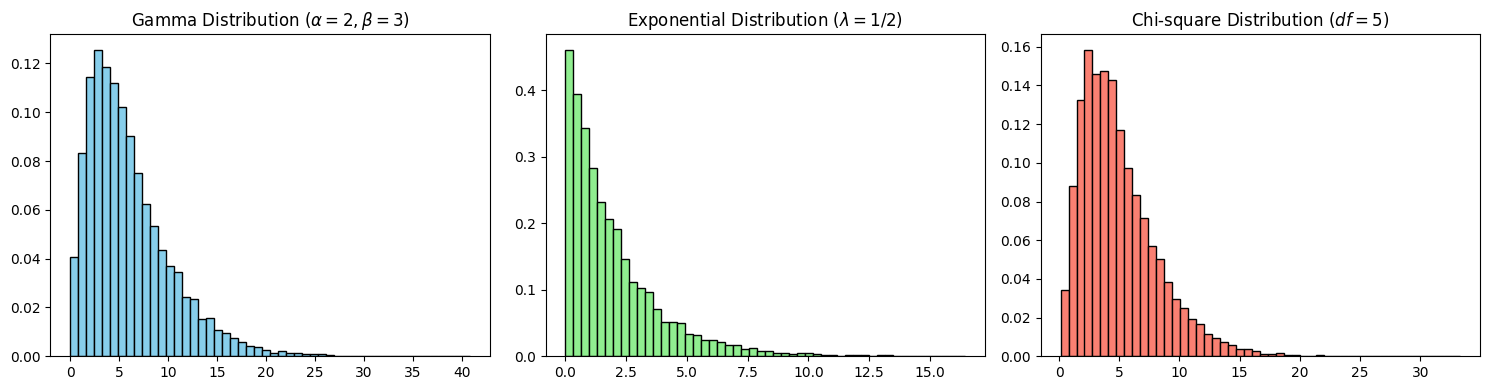

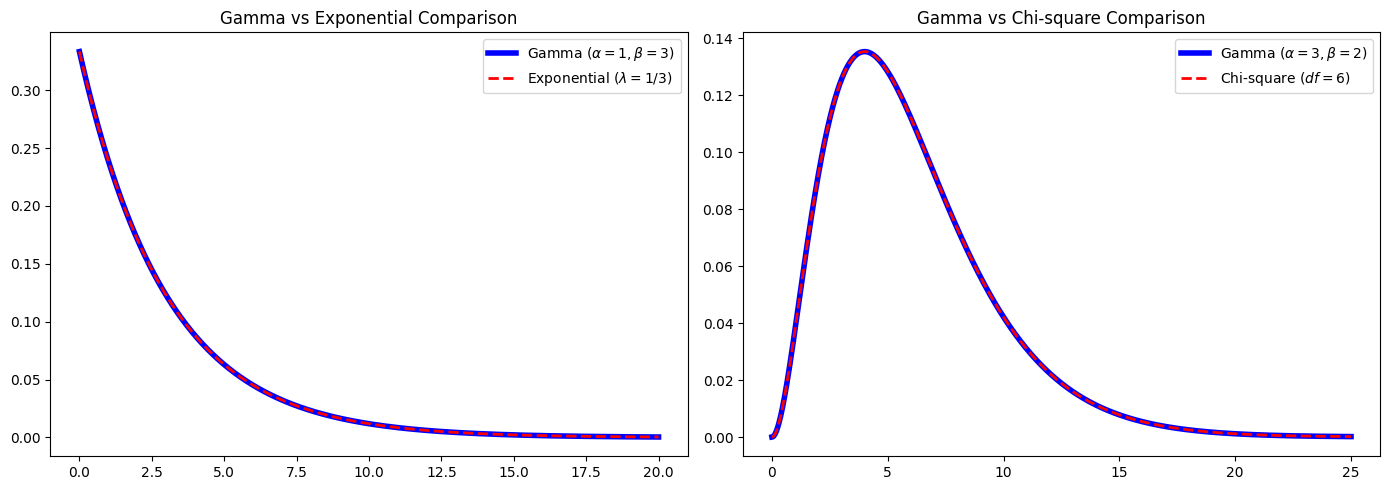

In [ ]:
N = 10000

print("=== 1. 분포의 이론적 평균/분산 및 표본의 평균/분산 ===")

alpha_gamma, beta_gamma = 2, 3
gamma_samples = np.random.gamma(shape=alpha_gamma, scale=beta_gamma, size=N)

gamma_theo_mean = alpha_gamma * beta_gamma
gamma_theo_var = alpha_gamma * (beta_gamma**2)

print(f" - 이론적 평균: {gamma_theo_mean:.4f}, 이론적 분산: {gamma_theo_var:.4f}")
print(f" - 표본 평균:   {np.mean(gamma_samples):.4f}, 표본 분산:   {np.var(gamma_samples):.4f}")

# ---------------------------------------------------------
# 1.2 지수분포: lambda = 1/2
# 파이썬에서 지수분포의 scale 파라미터는 1/lambda 입니다.
# 이론적 평균 = 1/lambda, 분산 = 1/lambda^2
# ---------------------------------------------------------
lam_exp = 1/2
scale_exp = 1 / lam_exp
exp_samples = np.random.exponential(scale=scale_exp, size=N)

exp_theo_mean = 1 / lam_exp
exp_theo_var = 1 / (lam_exp**2)

print(f"\n[지수분포] lambda=1/2")
print(f" - 이론적 평균: {exp_theo_mean:.4f}, 이론적 분산: {exp_theo_var:.4f}")
print(f" - 표본 평균:   {np.mean(exp_samples):.4f}, 표본 분산:   {np.var(exp_samples):.4f}")

# ---------------------------------------------------------
# 1.3 카이제곱분포: 자유도(df) = 5
# 이론적 평균 = df, 분산 = 2 * df
# ---------------------------------------------------------
df_chi = 5
chi_samples = np.random.chisquare(df=df_chi, size=N)

chi_theo_mean = df_chi
chi_theo_var = 2 * df_chi

print(f"\n[카이제곱분포] 자유도=5")
print(f" - 이론적 평균: {chi_theo_mean:.4f}, 이론적 분산: {chi_theo_var:.4f}")
print(f" - 표본 평균:   {np.mean(chi_samples):.4f}, 표본 분산:   {np.var(chi_samples):.4f}")


# =========================================================
# 시각화 1: 각 분포의 샘플 히스토그램
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(gamma_samples, bins=50, density=True, color='skyblue', edgecolor='black')
axes[0].set_title(r'Gamma Distribution ($\alpha=2, \beta=3$)')

axes[1].hist(exp_samples, bins=50, density=True, color='lightgreen', edgecolor='black')
axes[1].set_title(r'Exponential Distribution ($\lambda=1/2$)')

axes[2].hist(chi_samples, bins=50, density=True, color='salmon', edgecolor='black')
axes[2].set_title(r'Chi-square Distribution ($df=5$)')

plt.tight_layout()
plt.show()


# =========================================================
# 시각화 2: 분포 모양 비교 (이론적 확률밀도함수 PDF 사용)
# =========================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# 2.1 감마분포(alpha=1, beta=3) vs 지수분포(lambda=1/3 -> scale=3)
x1 = np.linspace(0, 20, 1000)
pdf_gamma1 = gamma.pdf(x1, a=1, scale=3)
pdf_exp1 = expon.pdf(x1, scale=3)

axes2[0].plot(x1, pdf_gamma1, 'b-', lw=4, label=r'Gamma ($\alpha=1, \beta=3$)')
axes2[0].plot(x1, pdf_exp1, 'r--', lw=2, label=r'Exponential ($\lambda=1/3$)')
axes2[0].set_title('Gamma vs Exponential Comparison')
axes2[0].legend()

# 2.2 감마분포(alpha=3, beta=2) vs 카이제곱분포(자유도=6)
x2 = np.linspace(0, 25, 1000)
pdf_gamma2 = gamma.pdf(x2, a=3, scale=2)
pdf_chi2 = chi2.pdf(x2, df=6)

axes2[1].plot(x2, pdf_gamma2, 'b-', lw=4, label=r'Gamma ($\alpha=3, \beta=2$)')
axes2[1].plot(x2, pdf_chi2, 'r--', lw=2, label=r'Chi-square ($df=6$)')
axes2[1].set_title('Gamma vs Chi-square Comparison')
axes2[1].legend()

plt.tight_layout()
plt.show()